# VGG-style CNN on CIFAR-10 (Full Dataset)

This notebook implements a VGG-style Convolutional Neural Network trained on the CIFAR-10 dataset.

## Objectives:
- Train model on full dataset
- Monitor training & validation performance
- Visualize accuracy and loss
- Evaluate final test performance
- Save trained model
- Perform single image prediction

Dataset:
- 60,000 images (32x32 RGB)
- 10 classes

## Importing Required Libraries

We import TensorFlow, Keras modules, and plotting libraries.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

## Loading CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training: (50000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


## Data Augmentation

We apply transformations to improve model generalization.

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow(x_train, y_train, batch_size=64)
test_set = test_datagen.flow(x_test, y_test, batch_size=64)

## Building the VGG-style CNN

In [4]:
model = models.Sequential()

model.add(layers.Input(shape=(32,32,3)))

# Block 1
model.add(layers.Conv2D(64,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))

# Block 2
model.add(layers.Conv2D(128,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(128,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))

# Block 3
model.add(layers.Conv2D(256,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(256,3,padding='same',activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))

# Dense Layers
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251,786 (12.40 MB)

 Trainable params: 3,249,994 (12.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Compiling the Model

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the CNN

Below shows the green progress bar with training and validation metrics.

In [6]:
history = model.fit(
    training_set,
    validation_data=test_set,
    epochs=25
)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.3923 - loss: 1.7409 - val_accuracy: 0.5327 - val_loss: 1.3182
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5460 - loss: 1.2882 - val_accuracy: 0.5919 - val_loss: 1.2000
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6263 - loss: 1.0826 - val_accuracy: 0.6535 - val_loss: 1.0005
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6822 - loss: 0.9451 - val_accuracy: 0.6903 - val_loss: 0.9257
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7193 - loss: 0.8498 - val_accuracy: 0.7578 - val_loss: 0.7261
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7434 - loss: 0.7744 - val_accuracy: 0.7450 - val_loss: 0.7729
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7692 - loss: 0.7022 - val_accuracy: 0.7331 - val_loss: 0.8259
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7856 - loss: 0.6599 - 

## Training Results Visualization

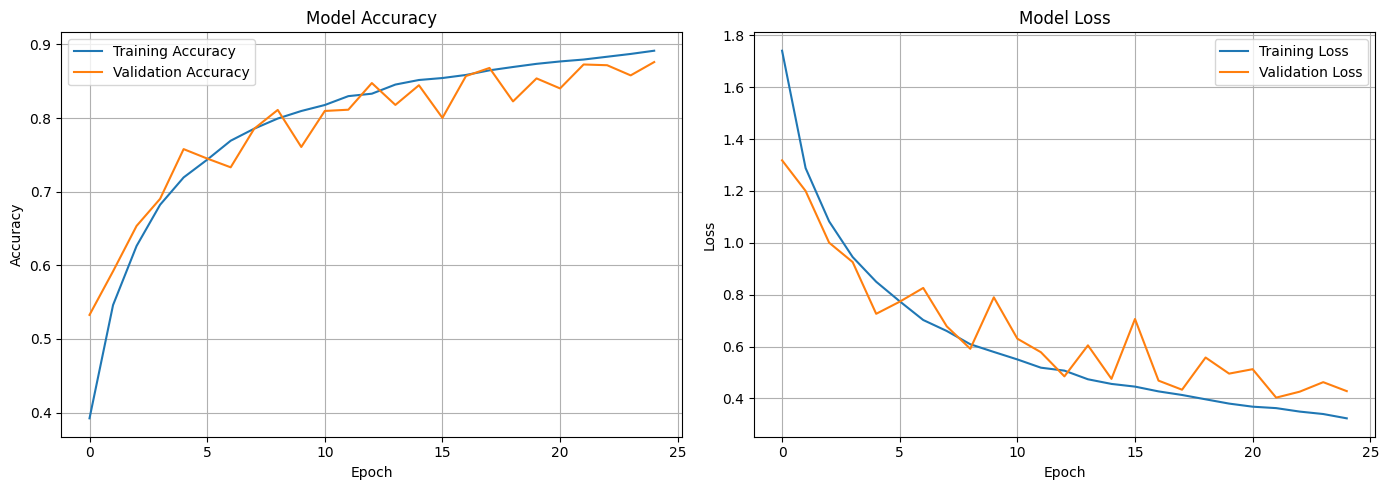

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Final Test set evaluation

In [8]:
test_loss, test_accuracy = model.evaluate(x_test / 255.0, y_test)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8760 - loss: 0.4279

Test Loss     : 0.4279
Test Accuracy : 0.8760


## Saving the trained model

In [9]:
model.save('cifar10_vgg_model.keras')

## Single Image Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: truck (100.00%)
Actual:    truck


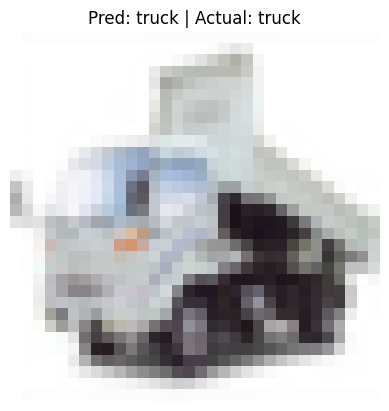

In [10]:
idx = np.random.randint(0, len(x_test))
test_image = x_test[idx]

img = test_image.astype('float32') / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

pred_class = np.argmax(prediction[0])
confidence = prediction[0][pred_class] * 100
actual_class = int(y_test[idx][0])

print(f"Predicted: {class_names[pred_class]} ({confidence:.2f}%)")
print(f"Actual:    {class_names[actual_class]}")

plt.imshow(test_image)
plt.title(f"Pred: {class_names[pred_class]} | Actual: {class_names[actual_class]}")
plt.axis('off')
plt.show()